# Credit Card Fraud Detection
super imbalanced dataset - only ~5% fraud
using isolation forest and an autoencoder trained only on normal transactions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# generate synthetic transaction data
n_legit = 9500
n_fraud = 500

legit = pd.DataFrame({
    'amount': np.random.lognormal(4.0, 1.0, n_legit).round(2),
    'hour': np.random.randint(8, 22, n_legit),
    'n_txns_24h': np.random.poisson(3, n_legit),
    'distance': np.random.exponential(20, n_legit).round(1),
    'velocity': np.random.beta(2, 8, n_legit).round(4),
    'merchant_risk': np.random.beta(1, 10, n_legit).round(4),
    'is_fraud': 0
})

# fraud has different patterns - large amounts, late night, far from home etc
fraud = pd.DataFrame({
    'amount': np.random.lognormal(6.0, 1.5, n_fraud).round(2),
    'hour': np.random.choice(list(range(0,6)) + list(range(22,24)), n_fraud),
    'n_txns_24h': np.random.poisson(15, n_fraud),
    'distance': np.random.exponential(300, n_fraud).round(1),
    'velocity': np.random.beta(8, 2, n_fraud).round(4),
    'merchant_risk': np.random.beta(5, 2, n_fraud).round(4),
    'is_fraud': 1
})

df = pd.concat([legit, fraud]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"total transactions: {len(df)}")
print(f"fraud rate: {df['is_fraud'].mean():.2%}")

total transactions: 10000
fraud rate: 5.00%


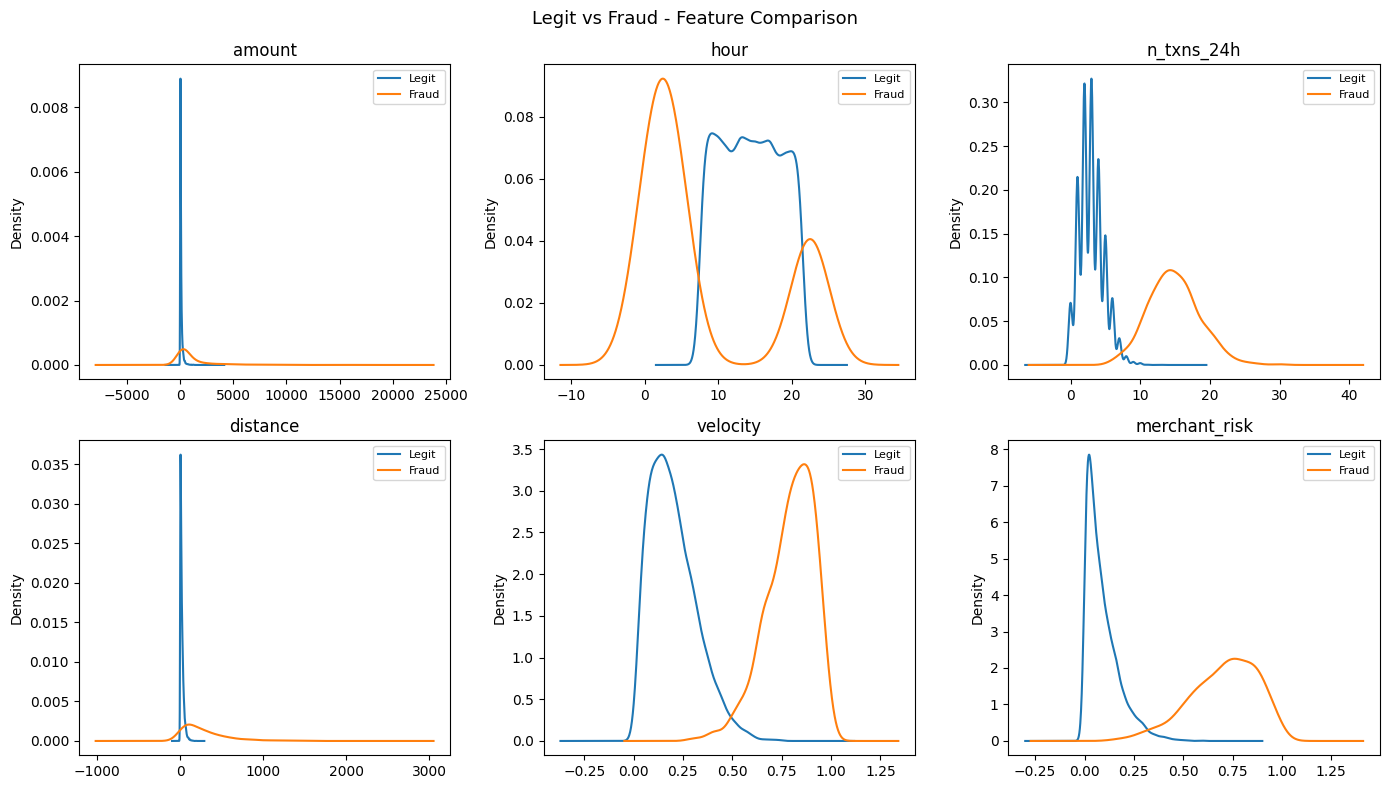

In [3]:
# visualize how fraud differs from legit
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
feats = ['amount', 'hour', 'n_txns_24h', 'distance', 'velocity', 'merchant_risk']

for ax, feat in zip(axes.flat, feats):
    df.groupby('is_fraud')[feat].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(feat)
    ax.legend(['Legit', 'Fraud'], fontsize=8)

plt.suptitle('Legit vs Fraud - Feature Comparison', fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
X = df.drop('is_fraud', axis=1).values
y = df['is_fraud'].values

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

In [5]:
# method 1: isolation forest
# doesnt need labels - finds outliers based on how easy they are to isolate
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso_preds = iso.fit_predict(X_sc)
iso_labels = (iso_preds == -1).astype(int)  # -1 means anomaly

print("Isolation Forest:")
print(classification_report(y, iso_labels, target_names=['Legit', 'Fraud']))

Isolation Forest:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      9500
       Fraud       1.00      1.00      1.00       500

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [6]:
# method 2: autoencoder
# train on legit only - fraud will have high reconstruction error

X_legit = X_sc[y == 0]
n_feats = X_sc.shape[1]

inp = keras.Input(shape=(n_feats,))
x = layers.Dense(8, activation='relu')(inp)
x = layers.Dense(4, activation='relu')(x)  # bottleneck
x = layers.Dense(8, activation='relu')(x)
out = layers.Dense(n_feats)(x)

ae = keras.Model(inp, out)
ae.compile(optimizer='adam', loss='mse')

ae.fit(X_legit, X_legit, epochs=30, batch_size=64,
       validation_split=0.1, verbose=0)
print("autoencoder trained")

autoencoder trained


In [7]:
# compute reconstruction errors
X_reconstructed = ae.predict(X_sc, verbose=0)
errors = np.mean(np.square(X_sc - X_reconstructed), axis=1)

# threshold = 95th percentile of legit errors
threshold = np.percentile(errors[y == 0], 95)
ae_preds = (errors > threshold).astype(int)

print(f"threshold: {threshold:.6f}")
print()
print("Autoencoder:")
print(classification_report(y, ae_preds, target_names=['Legit', 'Fraud']))

threshold: 0.065558

Autoencoder:
              precision    recall  f1-score   support

       Legit       1.00      0.95      0.97      9500
       Fraud       0.50      0.96      0.66       500

    accuracy                           0.95     10000
   macro avg       0.75      0.96      0.82     10000
weighted avg       0.97      0.95      0.96     10000



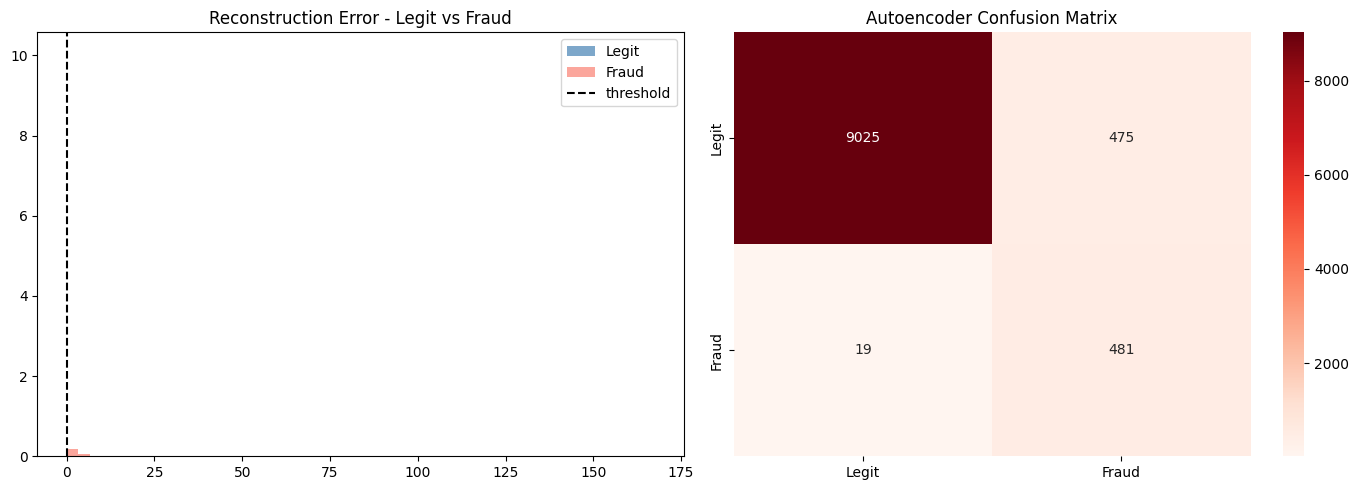

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# reconstruction errors by class
axes[0].hist(errors[y == 0], bins=50, alpha=0.7, label='Legit',
             color='steelblue', density=True)
axes[0].hist(errors[y == 1], bins=50, alpha=0.7, label='Fraud',
             color='salmon', density=True)
axes[0].axvline(threshold, color='black', linestyle='--', label='threshold')
axes[0].set_title('Reconstruction Error - Legit vs Fraud')
axes[0].legend()

# confusion matrix for autoencoder
cm = confusion_matrix(y, ae_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Legit','Fraud'],
            yticklabels=['Legit','Fraud'])
axes[1].set_title('Autoencoder Confusion Matrix')

plt.tight_layout()
plt.show()